In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys, os

sys.path.append(os.path.abspath("../src"))

from preprocessor import build_preprocessor, prepare_X_y
from evaluate import evaluate_model, plot_evaluation

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
import joblib

FEATURES_PATH = "../data/processed/churn_features.csv"
FIGURES_PATH  = "../reports/figures"
MODELS_PATH   = "../models"

print("Imports successful")

Imports successful


In [8]:
df = pd.read_csv(FEATURES_PATH)
X, y = prepare_X_y(df)

print(f"Feature matrix shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")
print(f"Churn rate: {y.mean()*100:.2f}%")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y       
)

print(f"\nTrain size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")
print(f"Train churn rate: {y_train.mean()*100:.2f}%")
print(f"Test churn rate:  {y_test.mean()*100:.2f}%")


Feature matrix shape: (7043, 25)
Target distribution:
churned
0    5174
1    1869
Name: count, dtype: int64
Churn rate: 26.54%

Train size: 5634 | Test size: 1409
Train churn rate: 26.54%
Test churn rate:  26.54%


In [7]:
preprocessor = build_preprocessor()

baseline_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier",   LogisticRegression(
        max_iter=1000,
        class_weight="balanced", 
        random_state=42,
        solver="lbfgs"
    ))
])

baseline_pipeline.fit(X_train, y_train)
print("Baseline model trained successfully")

Baseline model trained successfully


In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    baseline_pipeline, X_train, y_train,
    cv=cv,
    scoring=["roc_auc", "f1", "precision", "recall"],
    return_train_score=True
)

print("=== 5-FOLD CROSS-VALIDATION RESULTS (TRAIN SET) ===")
for metric in ["roc_auc", "f1", "precision", "recall"]:
    test_scores  = cv_results[f"test_{metric}"]
    train_scores = cv_results[f"train_{metric}"]
    print(f"\n{metric.upper()}")
    print(f"  CV Mean:   {test_scores.mean():.4f} (+/- {test_scores.std()*2:.4f})")
    print(f"  Train Mean:{train_scores.mean():.4f}")

=== 5-FOLD CROSS-VALIDATION RESULTS (TRAIN SET) ===

ROC_AUC
  CV Mean:   0.8413 (+/- 0.0220)
  Train Mean:0.8456

F1
  CV Mean:   0.6213 (+/- 0.0343)
  Train Mean:0.6292

PRECISION
  CV Mean:   0.5119 (+/- 0.0267)
  Train Mean:0.5187

RECALL
  CV Mean:   0.7906 (+/- 0.0599)
  Train Mean:0.7995



  Logistic Regression Baseline — Evaluation Results
  ROC_AUC         0.8358
  F1              0.6259
  PRECISION       0.5058
  RECALL          0.8209

              precision    recall  f1-score   support

    No Churn       0.92      0.71      0.80      1035
       Churn       0.51      0.82      0.63       374

    accuracy                           0.74      1409
   macro avg       0.71      0.77      0.71      1409
weighted avg       0.81      0.74      0.75      1409

Plot saved to ../reports/figures/08_baseline_evaluation.png


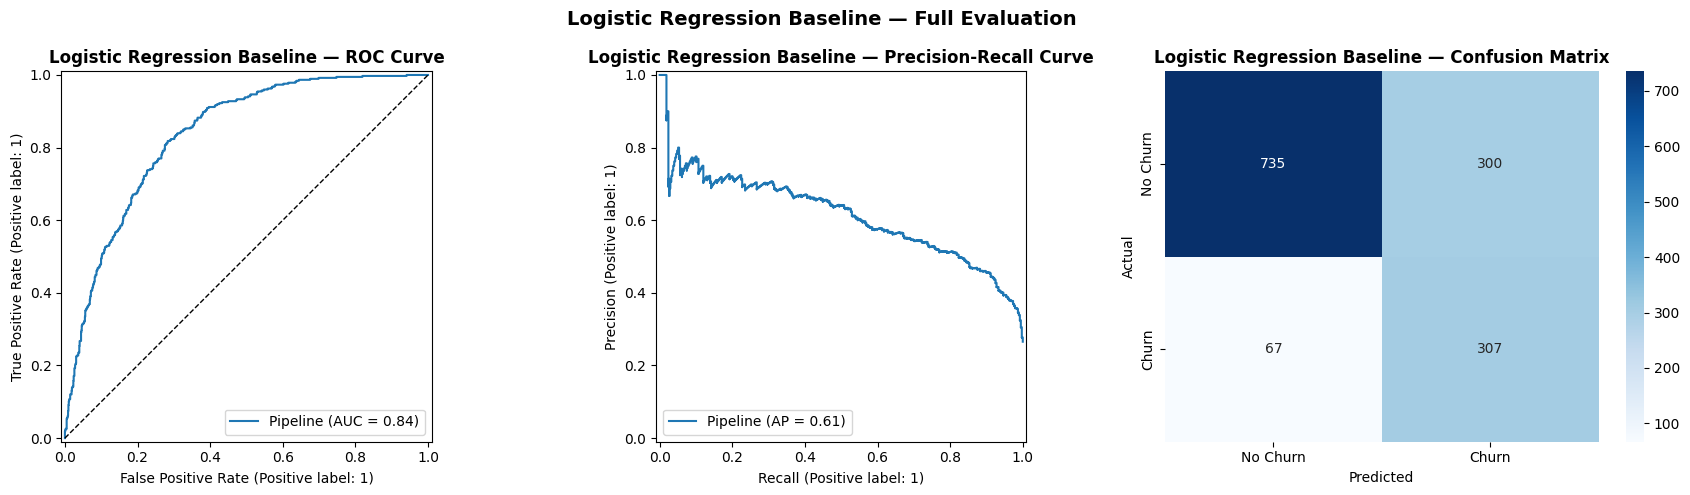

In [5]:
baseline_metrics = evaluate_model(
    baseline_pipeline, X_test, y_test,
    model_name="Logistic Regression Baseline"
)

plot_evaluation(
    baseline_pipeline, X_test, y_test,
    model_name="Logistic Regression Baseline",
    save_path=f"{FIGURES_PATH}/08_baseline_evaluation.png"
)

In [9]:
model_path = f"{MODELS_PATH}/baseline_logistic_regression.joblib"
joblib.dump(baseline_pipeline, model_path)
print(f"Baseline model saved to {model_path}")

Baseline model saved to ../models/baseline_logistic_regression.joblib


In [10]:
summary = f"""
=== BASELINE MODEL SUMMARY ===

Model:        Logistic Regression (class_weight='balanced')
Purpose:      Establish minimum performance threshold for XGBoost

Results:
  ROC-AUC:    {baseline_metrics['roc_auc']}
  F1 Score:   {baseline_metrics['f1']}
  Precision:  {baseline_metrics['precision']}
  Recall:     {baseline_metrics['recall']}

Why these metrics matter in fintech churn:
- ROC-AUC measures ranking quality across all thresholds
- Recall is critical: missing a churner (false negative) costs more
  than a false alarm (false positive) in retention campaigns
- A model that predicts 'No churn' for everyone gets 74% accuracy
  but 0.0 recall — this baseline should significantly outperform that

Next step: XGBoost model — expected to improve ROC-AUC by 5-10 points
"""
print(summary)


=== BASELINE MODEL SUMMARY ===

Model:        Logistic Regression (class_weight='balanced')
Purpose:      Establish minimum performance threshold for XGBoost

Results:
  ROC-AUC:    0.8358
  F1 Score:   0.6259
  Precision:  0.5058
  Recall:     0.8209

Why these metrics matter in fintech churn:
- ROC-AUC measures ranking quality across all thresholds
- Recall is critical: missing a churner (false negative) costs more
  than a false alarm (false positive) in retention campaigns
- A model that predicts 'No churn' for everyone gets 74% accuracy
  but 0.0 recall — this baseline should significantly outperform that

Next step: XGBoost model — expected to improve ROC-AUC by 5-10 points

